In [50]:
import _sqlite3
import pandas as pd
import numpy as np
import glob
from pathlib import Path
import matplotlib.pyplot as plt
import shutil

# The project paths
ROOT = Path("..") # This notebook is not in the root
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"

db_path = PROCESSED_DIR / "milestone2.db"
conn = _sqlite3.connect(db_path)

df = pd.read_sql_query("SELECT * FROM merged_m2", conn)
display(df)

,state,week,covid_admissions,influenza_admissions,rsv_admissions,total_respiratory_admissions,aqi_mean,aqi_p90,aqi_max,days_reported,category,defining_parameter,era,baseline,spike_ratio,is_spike
0,AL,2021-10-09 00:00:00,1230.00,8.50,0.0,1238.50,34.580645,52.6,80,93,Good,Ozone,covid,177.44,6.979824,1
1,AL,2021-10-16 00:00:00,962.57,4.00,0.0,966.57,40.752577,57.0,67,97,Good,PM2.5,covid,177.44,5.447306,1
2,AL,2021-10-23 00:00:00,707.91,8.00,0.0,715.91,40.423913,55.0,65,92,Good,Ozone,covid,177.44,4.034660,1
3,AL,2021-10-30 00:00:00,554.86,8.86,0.0,563.72,30.712766,44.4,70,94,Good,Ozone,covid,177.44,3.176961,1
4,AL,2021-11-06 00:00:00,451.71,10.14,0.0,461.85,38.166667,52.0,57,66,Good,PM2.5,covid,177.44,2.602852,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13020,VT,2023-09-02 00:00:00,24.57,0.00,0.0,24.57,34.391304,43.8,47,23,Good,PM2.5,post_covid,17.40,1.412069,0
13021,VT,2023-09-09 00:00:00,25.29,0.14,0.0,25.43,48.681818,58.0,63,22,Moderate,PM2.5,post_covid,17.40,1.461494,0
13022,VT,2023-09-16 00:00:00,22.14,0.14,0.0,22.28,25.400000,35.1,42,20,Good,PM2.5,post_covid,17.40,1.280460,0
13023,VT,2023-09-23 00:00:00,24.48,0.71,0.0,25.19,27.086957,35.4,53,23,Good,Ozone,post_covid,17.40,1.447701,0


In [57]:
feature_cols = ['aqi_mean', 'era', 'is_spike']
df_encoded = df[feature_cols]
df_encoded = pd.get_dummies(df_encoded, columns=['era'], drop_first=True)
display(df_encoded)

,aqi_p90,is_spike,era_post_covid
0,52.6,1,False
1,57.0,1,False
2,55.0,1,False
3,44.4,1,False
4,52.0,1,False
...,...,...,...
13020,43.8,0,True
13021,58.0,0,True
13022,35.1,0,True
13023,35.4,0,True


In [69]:
df_post = df_encoded[df_encoded['era_post_covid'] == True]
display(df_post)

,aqi_p90,is_spike,era_post_covid
65,57.0,1,True
66,57.8,1,True
67,55.0,1,True
68,50.0,1,True
69,54.1,1,True
...,...,...,...
13020,43.8,0,True
13021,58.0,0,True
13022,35.1,0,True
13023,35.4,0,True


In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
import time

X = df_post.drop(columns=["is_spike", "era_post_covid"])
y = df_post["is_spike"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [78]:
# Logistic Regression Hyperparameter Tuning with K Fold Cross Validation
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=1804))
])

lr_param_grid = {
    'model__C': [0.1, 1.0, 10.0],
    'model__solver': ['liblinear', 'lbfgs']
}

k_folds = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

lr_grid_search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    cv=k_folds,
    scoring='accuracy',
    verbose=1,
    n_jobs=1
)

start_time = time.time()
lr_grid_search.fit(X_train, y_train)
lr_training_time = time.time() - start_time

print(f"Best LR parameters: {lr_grid_search.best_params_}")
print(f"Best LR CV score: {lr_grid_search.best_score_:.4f}")
print(f"LR training time: {lr_training_time:.2f} seconds")

Fitting 4 folds for each of 6 candidates, totalling 24 fits
Best LR parameters: {'model__C': 0.1, 'model__solver': 'lbfgs'}
Best LR CV score: 0.6458
LR training time: 0.21 seconds


In [79]:
# Access the model from your grid search pipeline
lr_model = lr_grid_search.best_estimator_.named_steps['model']
features = X.columns

# Create a DataFrame of coefficients
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': lr_model.coef_[0]})
print(f"Intercept: {lr_model.intercept_[0]}")
print(coef_df.sort_values(by='Coefficient', ascending=False))

Intercept: -0.6742030693354708
   Feature  Coefficient
0  aqi_p90     -0.41201


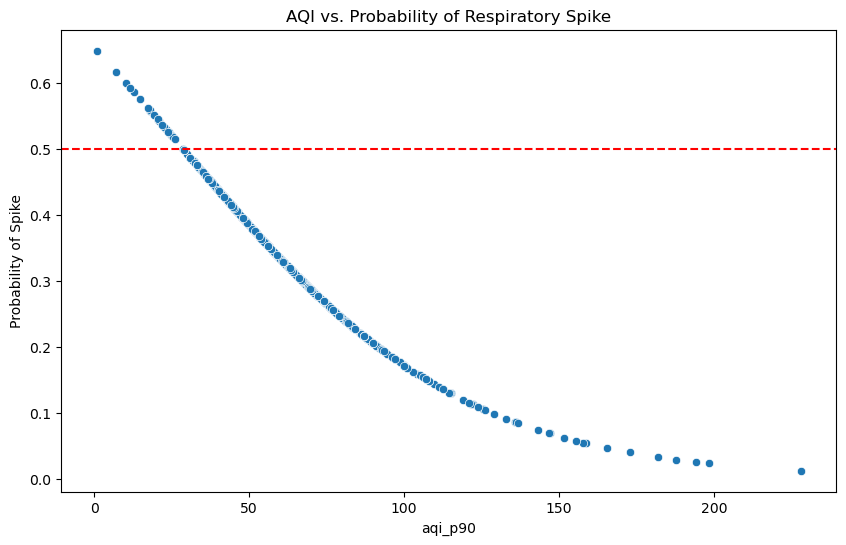

In [80]:
import numpy as np
import seaborn as sns

# Get probabilities for the test set
probs = lr_grid_search.predict_proba(X_test)[:, 1]

# Plot AQI vs Probability
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['aqi_p90'], y=probs)
plt.axhline(0.5, color='red', linestyle='--') # The 50% probability threshold
plt.title('AQI vs. Probability of Respiratory Spike')
plt.ylabel('Probability of Spike')
plt.show()

From testing the most basic linear models, there seems to be a backwards relationship with aqi and the probability of a spike occuring, this is likely due to the fact that the current model does not account for lag effects meaning that weeks following bad air quality may have spikes due to the previous weeks bad air quality. The current model cannot see that relationship so it confuses lower aqi with higher respiratory admissions (WIP will test more later)

In [81]:
rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(random_state=1804))
])

rf_param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [10, 20, None],
    'model__min_samples_split': [2, 5, 10]
}

k_folds = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=k_folds,
    scoring='recall',
    verbose=1,
    n_jobs=1
)

start_time = time.time()
rf_grid_search.fit(X_train, y_train)
rf_training_time = time.time() - start_time

print(f"Best RF parameters: {rf_grid_search.best_params_}")
print(f"Best RF CV score: {rf_grid_search.best_score_:.4f}")
print(f"RF training time: {rf_training_time:.2f} seconds")


Fitting 4 folds for each of 27 candidates, totalling 108 fits


KeyboardInterrupt: 

<Axes: title={'center': 'Feature Importance for Spikes'}>

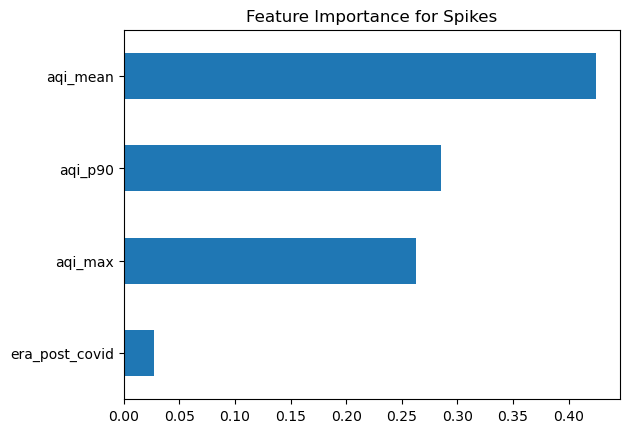

In [11]:
# Extract feature importance from your RF model
import pandas as pd
import matplotlib.pyplot as plt

rf_model = rf_grid_search.best_estimator_.named_steps['model']
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', title='Feature Importance for Spikes')